# Gaussian Mixture Model

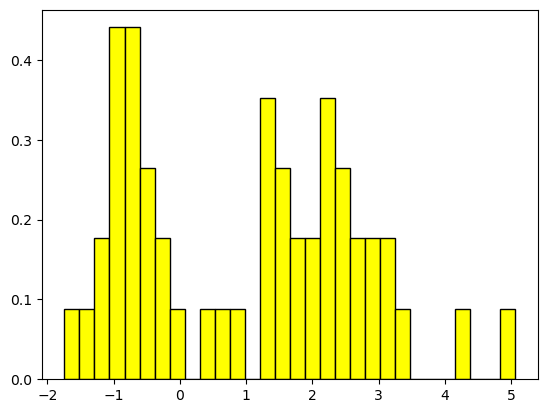

In [62]:
import numpy as np
import matplotlib.pyplot as plt

# Generate data
mu1, mu2 = -1, 2
std1, std2 = 0.4, 1

x1 = np.random.normal(loc=mu1, scale=std1, size=20)
x2 = np.random.normal(loc=mu2, scale=std2, size=30)
data = np.append(x1, x2)
N = len(data)

# Plot data
plt.hist(data, bins=30, color='yellow', edgecolor='black', density=True)
plt.show()


Init: [-0.63320584 -0.18311725 -2.09410684] : [0.1286665  1.17031599 0.03052289] : [0.33333333 0.33333333 0.33333333]


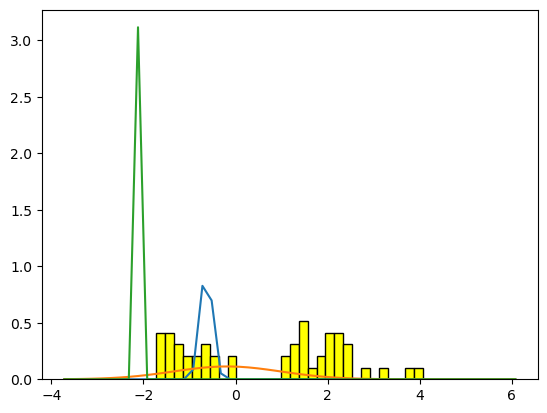

In [31]:
from scipy import stats

# Init random gaussians
K = 3

m0 = np.random.normal(size=K)
s0 = np.abs(np.random.normal(size=K))
W = np.full(K, 1/K)

print(f"Init: {m0} : {s0} : {W}")

pdfs = []
for i in range(K):
    pdf = stats.Normal(mu=m0[i], sigma=s0[i])
    pdfs.append(pdf)

x = np.linspace(data.min() - 2, data.max() + 2)

for i in range(K):
    plt.plot(x, W[i] * pdfs[i].pdf(x))
# plt.plot(x, sum(W[k] * pdfs[k].pdf(x) for k in range(K)), label="mixture")

plt.hist(data, bins=30, color='yellow', edgecolor='black', density=True)
plt.show()

In [32]:
def GMM_iter(data, pdfs, W, eps=0.01):

    K = len(pdfs)

    # E Step:
    LH = np.array([pdf.pdf(data) for pdf in pdfs]) # Likelihood
    R_denom = (W * LH.T).sum(axis=1)[:, None]
    R_denom = np.maximum(R_denom, eps)
    R = W * LH.T / R_denom # Responsibility

    # M Step:
    Nk = R.sum(axis=0)
    Nk_denom = np.where(Nk == 0, eps, Nk)

    # Update of means
    mu = data.T @ R / Nk_denom

    # Update of std
    cov = ((data[:, None] - mu)**2).T @ R / Nk_denom
    std = np.array([np.sqrt(cov[i, i]) for i in range(len(cov))])
    std = np.maximum(std, eps)

    # Update of weights
    W = Nk / N

    pdfs = np.array([stats.Normal(mu=mu[i], sigma=std[i]) for i in range(K)])

    return pdfs, W

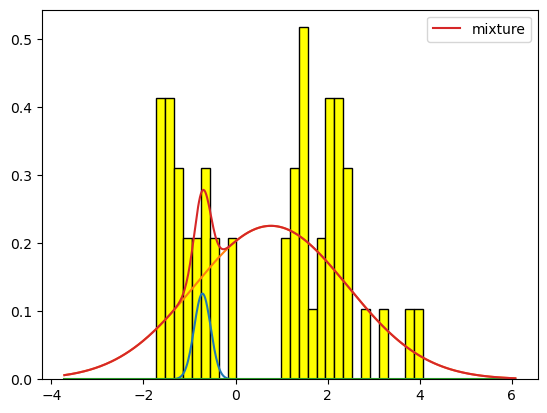

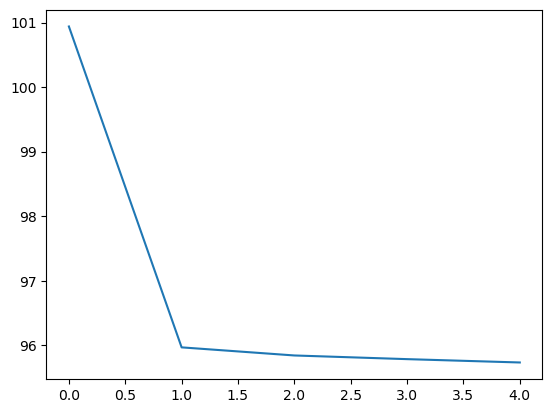

In [33]:
steps = 5
eps = 0.01

nllhs = []

for step in range(steps):
    pdfs, W = GMM_iter(data, pdfs, W, eps)

    mixture_pdf = sum(W[k] * pdfs[k].pdf(data) for k in range(K))
    nllh = -np.log(np.maximum(mixture_pdf, eps)).sum()
    nllhs.append(nllh)


# Plot Gaussians
x = np.linspace(data.min() - 2, data.max() + 2, 500)

for k in range(K):
    plt.plot(x, W[k] * pdfs[k].pdf(x))
plt.plot(x, sum(W[k] * pdfs[k].pdf(x) for k in range(K)), label="mixture")
# Plot data
plt.hist(data, bins=30, density=True, color="yellow", edgecolor="black")
plt.legend()
plt.show()
# Plot negative log-likelihood
plt.plot(range(steps), nllhs)
plt.show()

# 3D

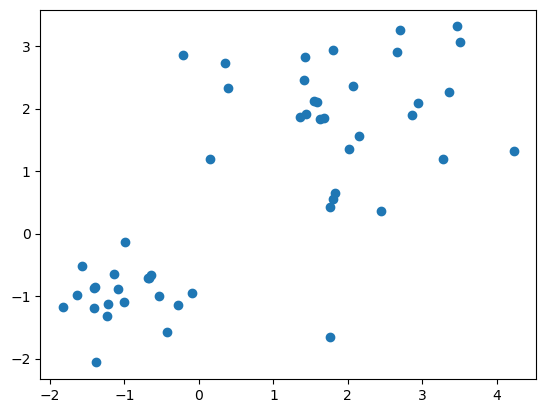

In [109]:
# Generate data
n1, n2 = 20, 30
mu1, mu2 = -1, 2
std1, std2 = 0.4, 1

x1 = np.random.normal(loc=mu1, scale=std1, size=[n1, 2])
x2 = np.random.normal(loc=mu2, scale=std2, size=[n2, 2])

data_x = np.append(x1[:, 0], x2[:, 0])
data_y = np.append(x1[:, 1], x2[:, 1])
data = np.array([data_x, data_y]).T

N = n1 + n2

# Plot data
plt.scatter(data_x, data_y)
plt.show()

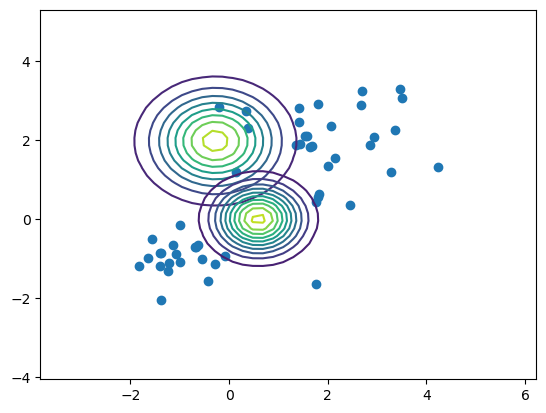

In [110]:
# Init random gaussians
K = 2

mu = np.random.normal(size=[K, 2])
cov = np.eye(2) @ np.abs(np.random.normal(size=[K]))
W = np.full(K, 1/K)


pdfs = [
    stats.multivariate_normal(mean=mu[k], cov=cov[k])
    for k in range(K)
]

x = np.linspace(data_x.min() - 2, data_x.max() + 2)
y = np.linspace(data_y.min() - 2, data_y.max() + 2)
xx, yy = np.meshgrid(x, y)
grid = np.column_stack([xx.ravel(), yy.ravel()])

for k in range(K):
    Z = W[k] * pdfs[k].pdf(grid)
    Z = Z.reshape(xx.shape)
    plt.contour(xx, yy, Z, levels=10)

plt.scatter(data_x, data_y)
plt.show()